# P02.ipynb

## 상담봇
### State
```
user_input: str  # 사용자 메세지
sentiment: str (positive, negative, agreesive)
core_msg: str
warning_count: int  # 상담할때, 공격적인 언행을 하면 경고 누적 횟수
response: str  # 답변
```
### Node
- `block_user`: 제공
- `analyze_sentiment`: LLM이 `user_input` 을 분석하여 `sentiment`를 `['positive', 'negative', 'agreesive']` 중 한가지로만 세팅
- `positive_node`: 제공
- `negative_node`: 제공
- `aggressive_node`: 제공
- `make_final_msg`: LLM이 `core_msg` 를 보고 최종 답변 생성

### Router
- `block_router` : `state['warning_count']`를 확인(3이상인지)하고 다음 노드 결정
- `emotion_router`: 단순히 `state['sentiment']`를 보고 다음 노드 결정

### Flow
#### ※ TD(top-down) 위아래, LR(left-Right) 좌우 차트 보여주는 방식,  '''는 코드펜스 라고 부름
```mermaid
flowchart TD
    START([START]) --> block_router{block_router}
    
    %% START 분기
    block_router -->|gogo| analyze_sentiment[analyze_sentiment]
    block_router -->|block| block_user[block_user]
    
    %% block_user 종료
    block_user --> END([END])
    
    %% 감정 분석 후 분기
    analyze_sentiment --> emotion_router{emotion_router}
    emotion_router -->|positive| positive_node[positive_node]
    emotion_router -->|negative| negative_node[negative_node]
    emotion_router -->|aggressive| aggressive_node[aggressive_node]
    
    %% 최종 메시지 생성으로 모임
    positive_node --> make_final_msg[make_final_msg]
    negative_node --> make_final_msg[make_final_msg]
    aggressive_node --> make_final_msg[make_final_msg]
    
    %% 최종 메시지 종료
    make_final_msg --> END
```

In [8]:
import random
from typing import TypedDict
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain.chat_models import init_chat_model
from langgraph.graph import StateGraph, START, END

# LLM 선언
llm = init_chat_model('openai:gpt-4.1-mini')

In [9]:
# state 정의

class ChatState(TypedDict):
    user_input: str      # 사용자 메세지
    sentiment: str       # positive, negative, aggressive
    core_msg: str
    warning_count: int   # 상담할 때 공격적인 언행을 하면 경고 누적 횟수
    response: str        # 최종 답변

In [10]:
# def positive_node(state: ChatState):
#     msgs = ['최고', '멋져', '훌륭']
#     keyword = random.choice(msgs)
#     return {'core_msg': keyword}


# def negative_node(state: ChatState):
#     msgs = ['힘내', '위로', '괜찮']
#     keyword = random.choice(msgs)
#     return {'core_msg': keyword}


# def aggressive_node(state: ChatState):
#     # dict.get(a, b)  -> key a가 있으면, 해당 value. key a가 없으면 b가 나옴
#     count = state.get('warning_count', 0) + 1  # state에 'warning_count' 키가 있으면, 그대로 사용. 없으면 0
#     return {'core_msg':  '공격적인 표현은 삼가라', 'warning_count': count}


# def block_user(state: ChatState):
#     return {'response': '님 차단'}

# Node 정의

# [제공 노드 1] 차단 노드
def block_user(state: ChatState):
    print("--- [block_user] 실행 ---")
    return {'response': '님 차단'}

# [구현 노드 1] 감정 분석 노드 (LLM 활용)
def analyze_sentiment(state: ChatState):
    print("--- [analyze_sentiment] 실행 ---")
    prompt = ChatPromptTemplate.from_messages([
        (
            "system",
            "당신은 감정 분석가입니다. 사용자의 메시지를 분석하여 반드시 'positive', 'negative', 'aggressive' 중 정확히 단어 하나만 반환하세요.\n"
            "- positive: 칭찬, 만족, 감사, 호의적인 태도\n"
            "- negative: 단순 불만, 슬픔, 아쉬움, 아쉬운 피드백\n"
            "- aggressive: 욕설, 비하, 협박, 폭력적/공격적인 언행"
        ),
        ("human", "{user_input}")
    ])
    
    chain = prompt | llm | StrOutputParser()
    result = chain.invoke({"user_input": state["user_input"]}).strip().lower()
    
    # 안정적인 분기를 위한 키워드 매핑
    if "aggressive" in result:
        sentiment = "aggressive"
    elif "negative" in result:
        sentiment = "negative"
    else:
        sentiment = "positive"
        
    return {"sentiment": sentiment}

# [제공 노드 2] 긍정 노드
def positive_node(state: ChatState):
    print("--- [positive_node] 실행 ---")
    msgs = ['최고', '멋져', '훌륭']
    keyword = random.choice(msgs)
    return {'core_msg': keyword}

# [제공 노드 3] 부정 노드
def negative_node(state: ChatState):
    print("--- [negative_node] 실행 ---")
    msgs = ['힘내', '위로', '괜찮']
    keyword = random.choice(msgs)
    return {'core_msg': keyword}

# [제공 노드 4] 공격적 언행 노드
def aggressive_node(state: ChatState):
    print("--- [aggressive_node] 실행 ---")
    # dict.get(a, b) -> key a가 있으면 해당 value, 없으면 b
    count = state.get('warning_count', 0) + 1
    return {'core_msg': '공격적인 표현은 삼가라', 'warning_count': count}

# [구현 노드 2] 최종 메시지 생성 노드 (LLM 활용)
def make_final_msg(state: ChatState):
    print("--- [make_final_msg] 실행 ---")
    prompt = ChatPromptTemplate.from_messages([
        (
            "system",
            "당신은 고객 상담원입니다. 전달받은 [핵심 키워드/메시지]를 바탕으로 사용자에게 정중하고 자연스러운 최종 상담 답변을 작성하세요."
        ),
        (
            "human",
            "사용자 입력: {user_input}\n핵심 키워드/메시지: {core_msg}\n\n상담원 답변:"
        )
    ])
    
    chain = prompt | llm | StrOutputParser()
    final_res = chain.invoke({
        "user_input": state["user_input"],
        "core_msg": state["core_msg"]
    })
    return {"response": final_res}

In [11]:
# Router (Conditional Edge 함수)

def block_router(state: ChatState):
    """warning_count가 3 이상인지 확인하고 다음 경로 리턴"""
    warning = state.get('warning_count', 0)
    if warning >= 3:
        return 'block'
    return 'gogo'

def emotion_router(state: ChatState):
    """단순히 state['sentiment']를 보고 다음 경로 리턴"""
    return state['sentiment']

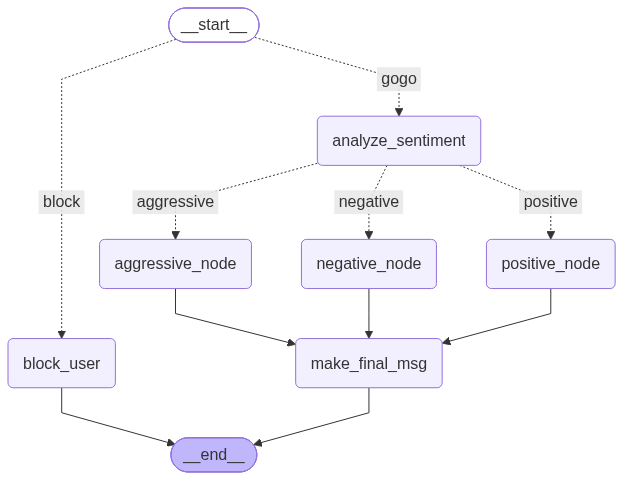

In [ ]:
# Graph 구성 및 연결

builder = StateGraph(ChatState)

# 노드 등록
builder.add_node("block_user", block_user)
builder.add_node("analyze_sentiment", analyze_sentiment)
builder.add_node("positive_node", positive_node)
builder.add_node("negative_node", negative_node)
builder.add_node("aggressive_node", aggressive_node)
builder.add_node("make_final_msg", make_final_msg)

# 1. START -> block_router 분기
builder.add_conditional_edges(
    START,
    block_router,
    {
        "gogo": "analyze_sentiment",
        "block": "block_user"
    }
)

# 2. block_user -> END
builder.add_edge("block_user", END)

# 3. analyze_sentiment -> emotion_router 분기
builder.add_conditional_edges(
    "analyze_sentiment",
    emotion_router,
    {
        "positive": "positive_node",
        "negative": "negative_node",
        "aggressive": "aggressive_node"
    }
)

# 4. 각 감정 노드 -> make_final_msg
builder.add_edge("positive_node", "make_final_msg")
builder.add_edge("negative_node", "make_final_msg")
builder.add_edge("aggressive_node", "make_final_msg")

# 5. make_final_msg -> END
builder.add_edge("make_final_msg", END)

# 컴파일
graph = builder.compile()
graph

In [13]:
# 실행 테스트

# ==========================================
# 결과 출력용 헬퍼 함수 (노드 아님, 단순 출력용)
# ==========================================
def print_counsel_result(title: str, state: dict):
    print(f"\n{'='*20} {title} {'='*20}")
    print(f"💬 사용자 입력 : {state.get('user_input', '-')}")
    
    # 차단되지 않고 감정 분석을 거친 경우에만 감정/키워드 출력
    if 'sentiment' in state:
        sentiment_kr = {
            'positive': '긍정 (positive) 😊',
            'negative': '부정 (negative) 😢',
            'aggressive': '공격적 (aggressive) 🚨'
        }.get(state['sentiment'], state['sentiment'])
        print(f"📊 감정 분석   : {sentiment_kr}")
        
    if 'core_msg' in state:
        print(f"🔑 핵심 키워드 : {state['core_msg']}")
        
    print(f"⚠️ 경고 횟수   : {state.get('warning_count', 0)}회")
    print(f"{'-'*50}")
    print(f"🤖 상담봇 답변 :\n{state.get('response', '-')}")
    print(f"{'='*52}")


# ==========================================
# 테스트 실행
# ==========================================
# 1. 긍정적인 표현
res1 = graph.invoke({
    "user_input": "배송도 빠르고 상품 상태도 너무 좋습니다!",
    "warning_count": 0
})
print_counsel_result("테스트 1: 긍정", res1)

# 2. 공격적인 표현
res2 = graph.invoke({
    "user_input": "야 상담원 똑바로 안 하냐? 당장 팀장 바꿔라.",
    "warning_count": 1
})
print_counsel_result("테스트 2: 공격적 표현", res2)

# 3. 차단 (경고 3회 이상)
res3 = graph.invoke({
    "user_input": "안녕하세요 문의드립니다.",
    "warning_count": 3
})
print_counsel_result("테스트 3: 차단", res3)

--- [analyze_sentiment] 실행 ---
--- [positive_node] 실행 ---
--- [make_final_msg] 실행 ---

==================== 테스트 1: 긍정 ====================
💬 사용자 입력 : 배송도 빠르고 상품 상태도 너무 좋습니다!
📊 감정 분석   : 긍정 (positive) 😊
🔑 핵심 키워드 : 멋져
⚠️ 경고 횟수   : 0회
--------------------------------------------------
🤖 상담봇 답변 :
진심 어린 칭찬에 감사드립니다! 앞으로도 멋진 상품과 빠른 배송으로 만족을 드릴 수 있도록 최선을 다하겠습니다. 언제든지 필요하신 점 있으시면 편하게 문의해 주세요!
--- [analyze_sentiment] 실행 ---
--- [aggressive_node] 실행 ---
--- [make_final_msg] 실행 ---

==================== 테스트 2: 공격적 표현 ====================
💬 사용자 입력 : 야 상담원 똑바로 안 하냐? 당장 팀장 바꿔라.
📊 감정 분석   : 공격적 (aggressive) 🚨
🔑 핵심 키워드 : 공격적인 표현은 삼가라
⚠️ 경고 횟수   : 2회
--------------------------------------------------
🤖 상담봇 답변 :
불편을 드려 죄송합니다. 고객님의 상황을 더욱 신속하고 정확하게 도와드리기 위해 최선을 다하겠습니다. 추가로 궁금하신 점이나 요청 사항 있으시면 언제든 말씀해 주세요.
--- [block_user] 실행 ---

==================== 테스트 3: 차단 ====================
💬 사용자 입력 : 안녕하세요 문의드립니다.
⚠️ 경고 횟수   : 3회
--------------------------------------------------
🤖 상담봇 답변 :
님 차단
